In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
#import pmdarima as pm

In [2]:
df = pd.read_csv('motul_data.csv')


In [3]:
# Tarih İndeksi Oluşturma
df['Date'] = pd.to_datetime(df['SalesYear'].astype(str) + '-' + df['SalesMonth'].astype(str), format='%Y-%m')
df.set_index('Date', inplace=True)
df

,ItemCode,ItemDescription,AttributeDescription,SalesYear,SalesMonth,TotalQty
Date,,,,,,
2019-01-01,303-101722,OUTBOARD SYNTH 2T 12X1L,MOTUL MOTOSİKLET,2019,1,0
2019-02-01,303-101722,OUTBOARD SYNTH 2T 12X1L,MOTUL MOTOSİKLET,2019,2,0
2019-03-01,303-101722,OUTBOARD SYNTH 2T 12X1L,MOTUL MOTOSİKLET,2019,3,0
2019-04-01,303-101722,OUTBOARD SYNTH 2T 12X1L,MOTUL MOTOSİKLET,2019,4,0
2019-05-01,303-101722,OUTBOARD SYNTH 2T 12X1L,MOTUL MOTOSİKLET,2019,5,0
...,...,...,...,...,...,...
2025-04-01,305-108587,300V² 4T FACTORY LINE 10W50 4X4L,MOTUL MOTOSİKLET,2025,4,0
2025-05-01,305-108587,300V² 4T FACTORY LINE 10W50 4X4L,MOTUL MOTOSİKLET,2025,5,0
2025-06-01,305-108587,300V² 4T FACTORY LINE 10W50 4X4L,MOTUL MOTOSİKLET,2025,6,0


In [4]:
# Her ürün için aylık satış miktarlarını matrise dönüştürme
sales_matrix = df.pivot_table(
    index='ItemCode',                # Ürünler satırlarda
    columns=df.index.to_period('M'),# Aylar sütunlarda (Yıl-Ay)
    values='TotalQty',              # Satış miktarı
    aggfunc='sum',                  # Toplam satış miktarı
    fill_value=0                    # Eksik değerler için 0
)
first_sale = df[df['TotalQty'] > 0].groupby('ItemCode').apply(lambda x: x.index.min())
last_sale = df[df['TotalQty'] > 0].groupby('ItemCode').apply(lambda x: x.index.max())

# sales_matrix'e ekleme
sales_matrix['İlk Satış Tarihi'] = first_sale
sales_matrix['Son Satış Tarihi'] = last_sale

sales_matrix

/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/3737027982.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  first_sale = df[df['TotalQty'] > 0].groupby('ItemCode').apply(lambda x: x.index.min())
/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/3737027982.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_sale = df[df['TotalQty'] > 0].groupby('ItemCode').apply(lambda x: x.ind

Date,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-101722,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2020-01-01,2024-09-01
303-101728,0,0,0,0,0,0,0,0,0,0,...,0,0,0,8,0,0,0,0,2021-08-01,2025-04-01
303-101743,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2020-06-01,2023-04-01
303-102788,0,0,0,12,24,0,24,12,9,12,...,12,12,0,24,36,36,1,1,2019-04-01,2025-08-01
303-102789,0,12,0,0,0,12,0,12,0,0,...,0,24,0,0,12,24,0,0,2019-02-01,2025-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-208849,0,0,0,0,0,0,0,0,0,0,...,31,6,25,0,0,0,0,0,2025-01-01,2025-03-01
303-208850,0,0,0,0,0,0,0,0,0,0,...,40,9,20,0,0,0,0,0,2025-01-01,2025-03-01
303-208851,0,0,0,0,0,0,0,0,0,0,...,15,13,24,0,0,0,0,0,2025-01-01,2025-03-01


In [5]:
# Son satış tarihi 2024-01-01'den önce olanları çıkarma
sales_matrix = sales_matrix[sales_matrix['Son Satış Tarihi'] >= '2024-01-01']
sales_matrix

Date,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-101722,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,2020-01-01,2024-09-01
303-101728,0,0,0,0,0,0,0,0,0,0,...,0,0,0,8,0,0,0,0,2021-08-01,2025-04-01
303-102788,0,0,0,12,24,0,24,12,9,12,...,12,12,0,24,36,36,1,1,2019-04-01,2025-08-01
303-102789,0,12,0,0,0,12,0,12,0,0,...,0,24,0,0,12,24,0,0,2019-02-01,2025-06-01
303-102981,60,259,84,140,289,347,252,336,72,108,...,0,0,0,0,0,0,0,0,2019-01-01,2024-06-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-114078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,60,72,48,0,2025-05-01,2025-07-01
303-208849,0,0,0,0,0,0,0,0,0,0,...,31,6,25,0,0,0,0,0,2025-01-01,2025-03-01
303-208850,0,0,0,0,0,0,0,0,0,0,...,40,9,20,0,0,0,0,0,2025-01-01,2025-03-01


In [6]:
# Özellik mühendisliği: Her ürün için anlamlı özellikler çıkarma

monthly_sales = sales_matrix.select_dtypes(include=[np.number])

features = pd.DataFrame({
    'Toplam Satış': monthly_sales.sum(axis=1),
    'Ortalama Aylık Satış': monthly_sales.mean(axis=1),
    'Satış Std Sapma': monthly_sales.std(axis=1),
    'Satış Yapılan Ay Sayısı': (monthly_sales > 0).sum(axis=1)
})

sales_matrix = sales_matrix.join(features)
sales_matrix.head()

monthly_sales


Date,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-101722,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
303-101728,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,8,0,0,0,0
303-102788,0,0,0,12,24,0,24,12,9,12,...,12,12,12,12,0,24,36,36,1,1
303-102789,0,12,0,0,0,12,0,12,0,0,...,0,0,0,24,0,0,12,24,0,0
303-102981,60,259,84,140,289,347,252,336,72,108,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-114078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,60,72,48,0
303-208849,0,0,0,0,0,0,0,0,0,0,...,0,0,31,6,25,0,0,0,0,0
303-208850,0,0,0,0,0,0,0,0,0,0,...,0,0,40,9,20,0,0,0,0,0


In [7]:
# Ürünlerin ilk satışından son satışı arasında kaç ay var
sales_matrix['Satış Süresi (Ay)'] = (
    (sales_matrix['Son Satış Tarihi'].dt.year - sales_matrix['İlk Satış Tarihi'].dt.year) * 12 +
    (sales_matrix['Son Satış Tarihi'].dt.month - sales_matrix['İlk Satış Tarihi'].dt.month) + 1
)


#  Satış Yapılan Ay Sayısı, Satış Süresi (Ay)'ın yarısından az olan ürünleri çıkarma
sales_matrix = sales_matrix[sales_matrix['Satış Yapılan Ay Sayısı'] >= (sales_matrix['Satış Süresi (Ay)'] / 3)]

# İlk satışı 2024-01-01'den sonra olanları çıkarma
sales_matrix = sales_matrix[sales_matrix['İlk Satış Tarihi'] < '2024-01-01']


# features'tan çıkarma
features = features[features.index.isin(sales_matrix.index)]

# ADI değeri olarak Satış Süresi (Ay) / Satış Yapılan Ay Sayısı
features['ADI'] = sales_matrix['Satış Süresi (Ay)'] / features['Satış Yapılan Ay Sayısı']

In [8]:
# Sadece özellik sütunlarını seçme
feature_cols = ['Toplam Satış', 'Ortalama Aylık Satış', 'Satış Std Sapma', 'Satış Yapılan Ay Sayısı', 'ADI']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features[feature_cols])

# Sonuç
features_scaled_df = pd.DataFrame(features_scaled, index=features.index, columns=feature_cols)
features_scaled_df

,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,ADI
ItemCode,,,,,
303-102788,-0.178798,-0.178798,-0.223723,0.543506,-0.436828
303-102981,-0.083542,-0.083542,-0.062986,-0.075584,-0.217558
303-102982,-0.162040,-0.162040,-0.191437,0.353017,-0.659175
303-102986,-0.184447,-0.184447,-0.228959,-0.694674,1.502709
303-102990,-0.174641,-0.174641,-0.219709,0.353017,-0.238227
...,...,...,...,...,...
303-111659,-0.183993,-0.183993,-0.223695,-1.170897,-0.572827
303-111762,-0.145101,-0.145101,-0.119954,-1.218519,-0.792922
303-111829,-0.184469,-0.184469,-0.223500,-1.456631,-0.547642


In [9]:
# DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=8)
dbscan_labels = dbscan.fit_predict(features_scaled_df)

sales_matrix['DBSCAN_Küme'] = dbscan_labels

# Küme dağılımı
print(sales_matrix['DBSCAN_Küme'].value_counts())
sales_matrix

DBSCAN_Küme
 0    90
 1    11
-1     8
Name: count, dtype: int64


,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-102788,0,0,0,12,24,0,24,12,9,12,...,1,1,2019-04-01,2025-08-01,1847,23.0875,28.459251,60,77,0
303-102981,60,259,84,140,289,347,252,336,72,108,...,0,0,2019-01-01,2024-06-01,15068,188.3500,235.801252,47,66,0
303-102982,12,12,24,12,0,24,132,0,24,72,...,0,0,2019-01-01,2024-05-01,4173,52.1625,70.106509,56,65,0
303-102986,12,0,0,12,0,0,0,0,10,0,...,0,24,2019-01-01,2025-08-01,1063,13.2875,21.704689,34,80,0
303-102990,0,0,24,0,36,24,84,36,0,0,...,52,13,2019-03-01,2025-08-01,2424,30.3000,33.637080,56,78,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-111659,0,0,0,0,0,0,0,0,0,0,...,0,48,2023-04-01,2025-08-01,1126,14.0750,28.495070,24,29,1
303-111762,0,0,0,0,0,0,0,0,0,0,...,312,216,2023-08-01,2025-08-01,6524,81.5500,162.314814,23,25,1
303-111829,0,0,0,0,0,0,0,0,0,0,...,36,0,2023-10-01,2025-07-01,1060,13.2500,28.747042,18,22,1


In [10]:
mean = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].mean()
median = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].median()
std = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].std()
cv = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].std() / sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].mean()
iqr = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].quantile(0.75) - sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].quantile(0.25)
range = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].max() - sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].min()
Skewness = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].skew()
Kurtosis = sales_matrix.groupby('DBSCAN_Küme')['Ortalama Aylık Satış'].apply(pd.Series.kurtosis)

# Sonuçları birleştirme
istatistikler = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Std': std,
    'CV': cv,
    'IQR': iqr,
    'Range': range,
    'Skewness': Skewness,
    'Kurtosis': Kurtosis
})

istatistikler

,Mean,Median,Std,CV,IQR,Range,Skewness,Kurtosis
DBSCAN_Küme,,,,,,,,
-1,3725.143750,1545.10625,5702.737758,1.530877,2055.959375,17318.5000,2.459830,6.290449
0,66.936806,27.38750,109.198052,1.631360,74.781250,614.3875,3.211638,11.651691
1,45.728409,18.13750,66.224359,1.448210,29.531250,226.0750,2.743385,7.963879


In [11]:
dbscan_cluster_outliers = sales_matrix[sales_matrix['DBSCAN_Küme'] == -1]
dbscan_cluster_outliers

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-104054,108,444,264,504,228,384,216,312,516,408,...,6804,3910,2019-01-01,2025-08-01,92823,1160.2875,1817.975653,79,80,-1
303-104066,252,1368,2758,1728,1143,1464,1576,3292,936,1668,...,6568,4704,2019-01-01,2025-08-01,409528,5119.1000,3994.635801,79,80,-1
303-104091,36,672,684,960,324,300,544,678,366,452,...,2739,2448,2019-01-01,2025-08-01,154394,1929.9250,1528.892855,80,80,-1
303-105879,0,0,0,0,0,0,0,0,0,0,...,0,0,2022-10-01,2024-06-01,31,0.3875,1.297454,7,21,-1
303-107672,1452,5764,10140,8448,1536,1672,9460,4118,3794,4962,...,17172,10224,2019-01-01,2025-08-01,1385511,17318.8875,12455.879642,80,80,-1
303-109793,0,0,0,0,0,0,0,0,1428,972,...,1236,588,2019-09-01,2025-08-01,189503,2368.7875,2478.317113,72,72,-1
303-111648,0,0,0,0,0,0,0,0,0,0,...,2028,181,2023-03-01,2025-08-01,68388,854.8500,1712.968540,30,30,-1
303-111658,0,0,0,0,0,0,0,0,0,0,...,1647,925,2023-02-01,2025-08-01,83914,1048.9250,2041.252016,30,31,-1


In [12]:
# küme 1
dbscan_cluster_1 = sales_matrix[sales_matrix['DBSCAN_Küme'] == 1]
dbscan_cluster_1

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-110442,0,0,0,0,0,0,0,0,0,0,...,156,36,2023-12-01,2025-08-01,1224,15.3000,36.024043,18,21,1
303-110873,0,0,0,0,0,0,0,0,0,0,...,95,47,2023-05-01,2025-08-01,1784,22.3000,48.305830,26,28,1
303-110879,0,0,0,0,0,0,0,0,0,0,...,120,72,2023-06-01,2025-08-01,3324,41.5500,95.134402,27,27,1
303-111034,0,0,0,0,0,0,0,0,0,0,...,275,48,2022-10-01,2025-08-01,1451,18.1375,40.715669,25,35,1
303-111649,0,0,0,0,0,0,0,0,0,0,...,663,168,2023-02-01,2025-08-01,18741,234.2625,380.389532,31,31,1
303-111650,0,0,0,0,0,0,0,0,0,0,...,96,84,2023-04-01,2025-08-01,3587,44.8375,86.285139,28,29,1
303-111651,0,0,0,0,0,0,0,0,0,0,...,12,36,2023-05-01,2025-08-01,655,8.1875,19.827799,21,28,1
303-111659,0,0,0,0,0,0,0,0,0,0,...,0,48,2023-04-01,2025-08-01,1126,14.0750,28.495070,24,29,1
303-111762,0,0,0,0,0,0,0,0,0,0,...,312,216,2023-08-01,2025-08-01,6524,81.5500,162.314814,23,25,1


In [13]:
# CV = Standart Sapma / Ortalama dbscan_cluster_1'a ekle
dbscan_cluster_1['CV'] = dbscan_cluster_1['Satış Std Sapma'] / dbscan_cluster_1['Ortalama Aylık Satış']
# Satış Yapılan Ay Yüzdesi = (Satış Yapılan Ay Sayısı / Toplam Satış Süresi (Ay)) * 100
dbscan_cluster_1['Satış Yapılan Ay Yüzdesi'] = (dbscan_cluster_1['Satış Yapılan Ay Sayısı'] / dbscan_cluster_1['Satış Süresi (Ay)']) * 100
dbscan_cluster_1

/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/2947932417.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbscan_cluster_1['CV'] = dbscan_cluster_1['Satış Std Sapma'] / dbscan_cluster_1['Ortalama Aylık Satış']
/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/2947932417.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbscan_cluster_1['Satış Yapılan Ay Yüzdesi'] = (dbscan_cluster_1['Satış Yapılan Ay Sayısı'] / dbscan_cluster_1['Satış Süresi (Ay)']) * 100


,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme,CV,Satış Yapılan Ay Yüzdesi
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-110442,0,0,0,0,0,0,0,0,0,0,...,2023-12-01,2025-08-01,1224,15.3000,36.024043,18,21,1,2.354513,85.714286
303-110873,0,0,0,0,0,0,0,0,0,0,...,2023-05-01,2025-08-01,1784,22.3000,48.305830,26,28,1,2.166181,92.857143
303-110879,0,0,0,0,0,0,0,0,0,0,...,2023-06-01,2025-08-01,3324,41.5500,95.134402,27,27,1,2.289637,100.000000
303-111034,0,0,0,0,0,0,0,0,0,0,...,2022-10-01,2025-08-01,1451,18.1375,40.715669,25,35,1,2.244834,71.428571
303-111649,0,0,0,0,0,0,0,0,0,0,...,2023-02-01,2025-08-01,18741,234.2625,380.389532,31,31,1,1.623775,100.000000
303-111650,0,0,0,0,0,0,0,0,0,0,...,2023-04-01,2025-08-01,3587,44.8375,86.285139,28,29,1,1.924397,96.551724
303-111651,0,0,0,0,0,0,0,0,0,0,...,2023-05-01,2025-08-01,655,8.1875,19.827799,21,28,1,2.421716,75.000000
303-111659,0,0,0,0,0,0,0,0,0,0,...,2023-04-01,2025-08-01,1126,14.0750,28.495070,24,29,1,2.024516,82.758621
303-111762,0,0,0,0,0,0,0,0,0,0,...,2023-08-01,2025-08-01,6524,81.5500,162.314814,23,25,1,1.990372,92.000000


In [14]:
# Küme 0
dbscan_cluster_0 = sales_matrix[sales_matrix['DBSCAN_Küme'] == 0]
dbscan_cluster_0

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,2025-07,2025-08,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-102788,0,0,0,12,24,0,24,12,9,12,...,1,1,2019-04-01,2025-08-01,1847,23.0875,28.459251,60,77,0
303-102981,60,259,84,140,289,347,252,336,72,108,...,0,0,2019-01-01,2024-06-01,15068,188.3500,235.801252,47,66,0
303-102982,12,12,24,12,0,24,132,0,24,72,...,0,0,2019-01-01,2024-05-01,4173,52.1625,70.106509,56,65,0
303-102986,12,0,0,12,0,0,0,0,10,0,...,0,24,2019-01-01,2025-08-01,1063,13.2875,21.704689,34,80,0
303-102990,0,0,24,0,36,24,84,36,0,0,...,52,13,2019-03-01,2025-08-01,2424,30.3000,33.637080,56,78,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-108713,0,0,0,0,0,0,0,0,0,0,...,8,8,2021-12-01,2025-08-01,188,2.3500,5.170755,19,45,0
303-108859,24,0,0,120,144,72,0,24,0,0,...,0,0,2019-01-01,2024-10-01,2898,36.2250,44.228113,50,70,0
303-108879,12,0,12,24,0,48,0,12,12,12,...,72,36,2019-01-01,2025-08-01,3312,41.4000,44.773862,60,80,0


In [15]:
 # CV = Standart Sapma / Ortalama dbscan_cluster_0'a ekle
dbscan_cluster_0['CV'] = dbscan_cluster_0['Satış Std Sapma'] / dbscan_cluster_0['Ortalama Aylık Satış']
# Satış Yapılan Ay Yüzdesi = (Satış Yapılan Ay Sayısı / Toplam Satış Süresi (Ay)) * 100
dbscan_cluster_0['Satış Yapılan Ay Yüzdesi'] = (dbscan_cluster_0['Satış Yapılan Ay Sayısı'] / dbscan_cluster_0['Satış Süresi (Ay)']) * 100
dbscan_cluster_0

/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/1624158384.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbscan_cluster_0['CV'] = dbscan_cluster_0['Satış Std Sapma'] / dbscan_cluster_0['Ortalama Aylık Satış']
/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/1624158384.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbscan_cluster_0['Satış Yapılan Ay Yüzdesi'] = (dbscan_cluster_0['Satış Yapılan Ay Sayısı'] / dbscan_cluster_0['Satış Süresi (Ay)']) * 100


,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,İlk Satış Tarihi,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme,CV,Satış Yapılan Ay Yüzdesi
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-102788,0,0,0,12,24,0,24,12,9,12,...,2019-04-01,2025-08-01,1847,23.0875,28.459251,60,77,0,1.232669,77.922078
303-102981,60,259,84,140,289,347,252,336,72,108,...,2019-01-01,2024-06-01,15068,188.3500,235.801252,47,66,0,1.251931,71.212121
303-102982,12,12,24,12,0,24,132,0,24,72,...,2019-01-01,2024-05-01,4173,52.1625,70.106509,56,65,0,1.344002,86.153846
303-102986,12,0,0,12,0,0,0,0,10,0,...,2019-01-01,2025-08-01,1063,13.2875,21.704689,34,80,0,1.633467,42.500000
303-102990,0,0,24,0,36,24,84,36,0,0,...,2019-03-01,2025-08-01,2424,30.3000,33.637080,56,78,0,1.110135,71.794872
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303-108713,0,0,0,0,0,0,0,0,0,0,...,2021-12-01,2025-08-01,188,2.3500,5.170755,19,45,0,2.200321,42.222222
303-108859,24,0,0,120,144,72,0,24,0,0,...,2019-01-01,2024-10-01,2898,36.2250,44.228113,50,70,0,1.220928,71.428571
303-108879,12,0,12,24,0,48,0,12,12,12,...,2019-01-01,2025-08-01,3312,41.4000,44.773862,60,80,0,1.081494,75.000000


In [16]:
cluster0_features = ['Ortalama Aylık Satış', 'Satış Std Sapma', 'Satış Yapılan Ay Yüzdesi']
X = dbscan_cluster_0[cluster0_features]

# StandardScaler 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [17]:
kmeans = KMeans(n_clusters=3, random_state=42)
dbscan_cluster_0['Alt_Küme'] = kmeans.fit_predict(X_scaled)
print(dbscan_cluster_0['Alt_Küme'].value_counts())

Alt_Küme
2    51
0    35
1     4
Name: count, dtype: int64


/var/folders/zw/g39yw30915xbs74yq9bznnmc0000gn/T/ipykernel_87617/407754154.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dbscan_cluster_0['Alt_Küme'] = kmeans.fit_predict(X_scaled)


In [18]:
subcluster_1 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 1]
subcluster_1

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme,CV,Satış Yapılan Ay Yüzdesi,Alt_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-104080,12,108,228,252,117,124,276,210,96,75,...,2025-08-01,32626,407.8250,412.849829,80,80,0,1.012321,100.000000,1
303-104089,0,60,12,156,396,792,528,528,804,288,...,2025-08-01,49157,614.4625,500.344032,78,79,0,0.814279,98.734177,1
303-105935,0,60,36,12,58,0,24,96,96,36,...,2025-08-01,43679,545.9875,886.001136,66,79,0,1.622750,83.544304,1
303-105960,12,108,192,60,240,72,48,24,108,204,...,2025-05-01,33902,423.7750,446.595305,77,77,0,1.053850,100.000000,1


In [19]:
subcluster_0 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 0]
subcluster_0

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme,CV,Satış Yapılan Ay Yüzdesi,Alt_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-102986,12,0,0,12,0,0,0,0,10,0,...,2025-08-01,1063,13.2875,21.704689,34,80,0,1.633467,42.500000,0
303-104024,0,0,12,12,0,0,12,0,0,13,...,2025-07-01,2089,26.1125,51.823213,48,77,0,1.984613,62.337662,0
303-104028,0,0,0,0,0,0,0,0,0,0,...,2025-07-01,611,7.6375,17.703067,29,68,0,2.317914,42.647059,0
303-104035,0,0,0,0,0,0,0,0,0,0,...,2025-08-01,136,1.7000,3.633180,21,54,0,2.137165,38.888889,0
303-104038,0,0,0,0,0,0,0,0,0,0,...,2025-08-01,1128,14.1000,27.521959,30,68,0,1.951912,44.117647,0
303-104058,0,0,2,0,1,0,0,0,0,0,...,2025-08-01,70,0.8750,2.136927,26,78,0,2.442202,33.333333,0
303-104070,2,0,1,3,0,0,0,0,0,0,...,2025-08-01,188,2.3500,3.311277,46,80,0,1.409054,57.500000,0
303-104077,0,0,0,0,0,0,0,0,0,0,...,2024-09-01,58,0.7250,1.792919,19,56,0,2.472991,33.928571,0
303-104090,8,8,4,0,0,4,16,44,0,0,...,2025-08-01,691,8.6375,13.579810,39,80,0,1.572192,48.750000,0


In [20]:
mean = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].mean()
median = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].median()
std = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].std()
cv = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].std() / dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].mean()
iqr = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].quantile(0.75) - dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].quantile(0.25)
range = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].max() - dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].min()
Skewness = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].skew()
Kurtosis = dbscan_cluster_0.groupby('Alt_Küme')['Ortalama Aylık Satış'].apply(pd.Series.kurtosis)

# Sonuçları birleştirme
istatistikler = pd.DataFrame({
    'Mean': mean,
    'Median': median,
    'Std': std,
    'CV': cv,
    'IQR': iqr,
    'Range': range,
    'Skewness': Skewness,
    'Kurtosis': Kurtosis
})

istatistikler

,Mean,Median,Std,CV,IQR,Range,Skewness,Kurtosis
Alt_Küme,,,,,,,,
0,7.545357,5.55000,6.431681,0.852402,7.57500,26.0375,1.298571,1.703092
1,498.012500,484.88125,99.175257,0.199142,143.31875,206.6375,0.373736,-3.655248
2,73.885784,52.16250,56.765601,0.768289,73.86250,224.6125,1.022519,0.151784


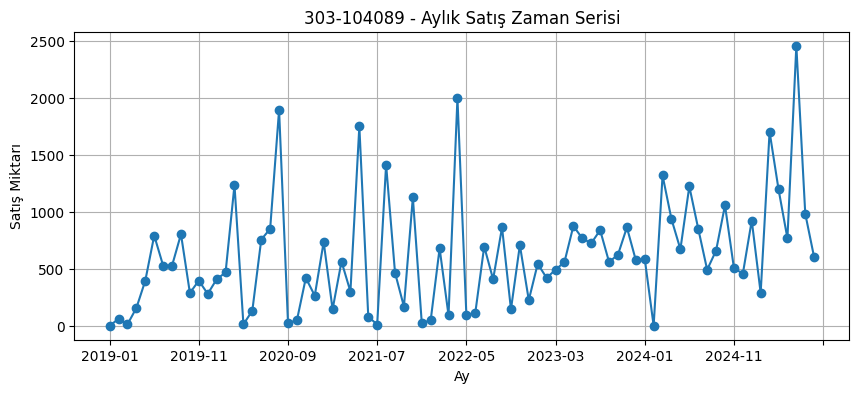

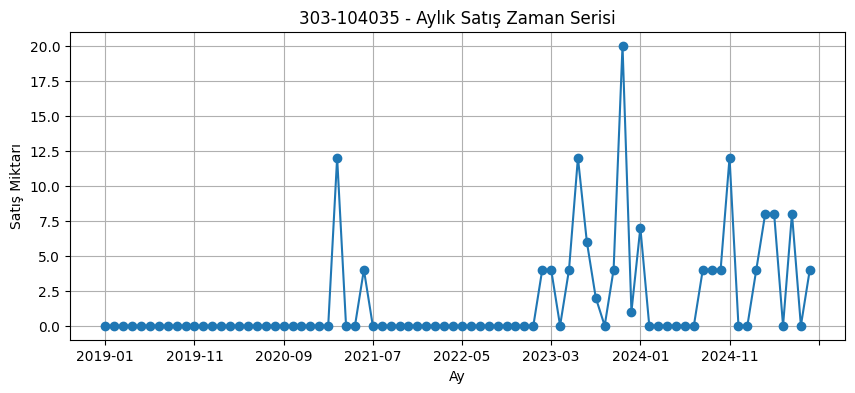

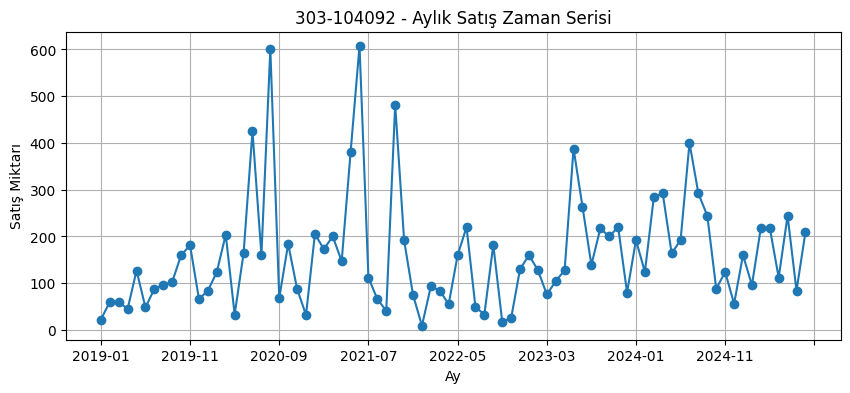

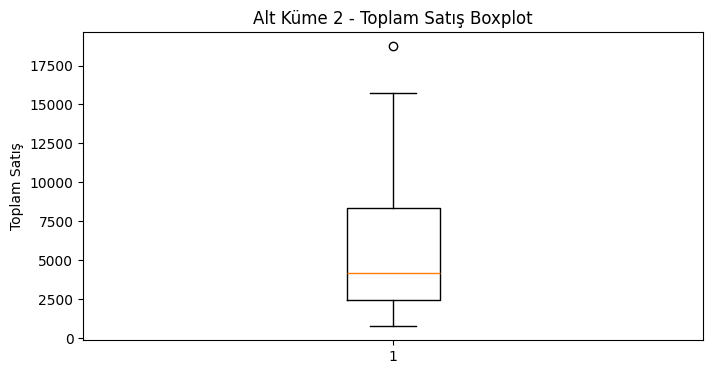

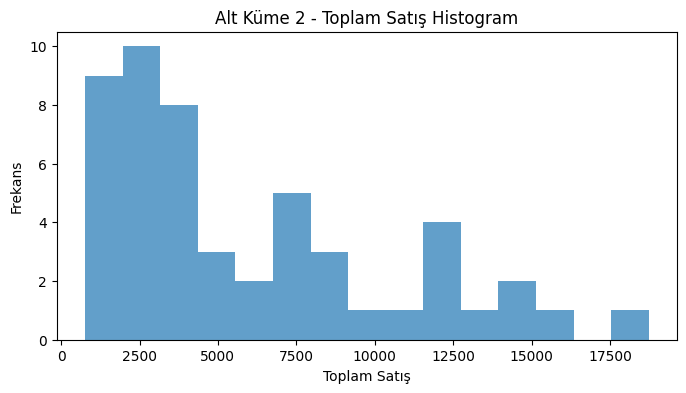

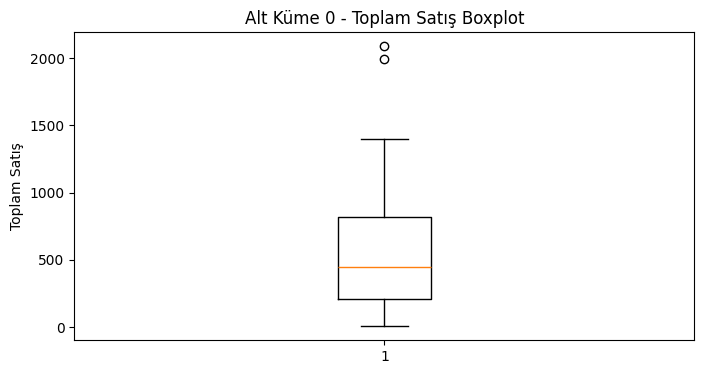

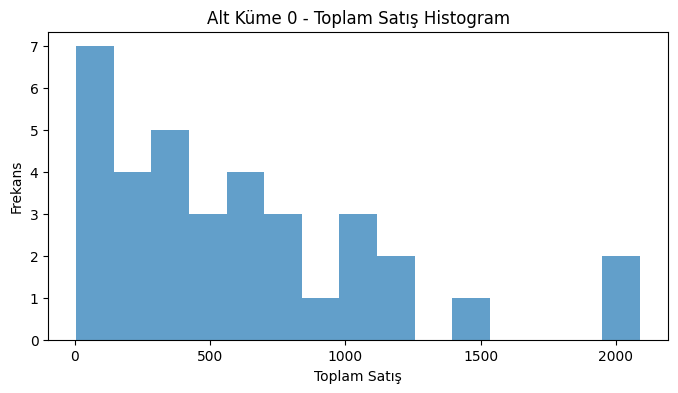

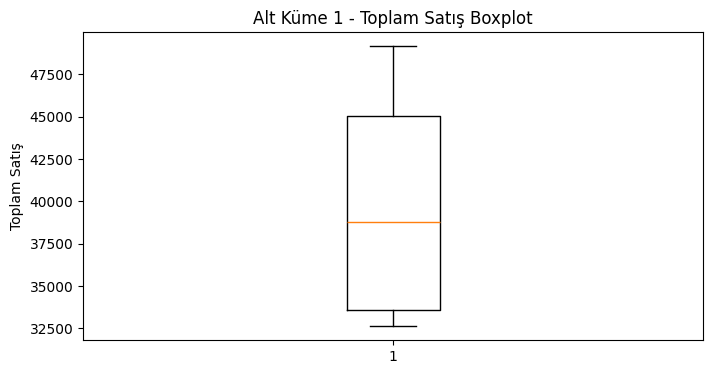

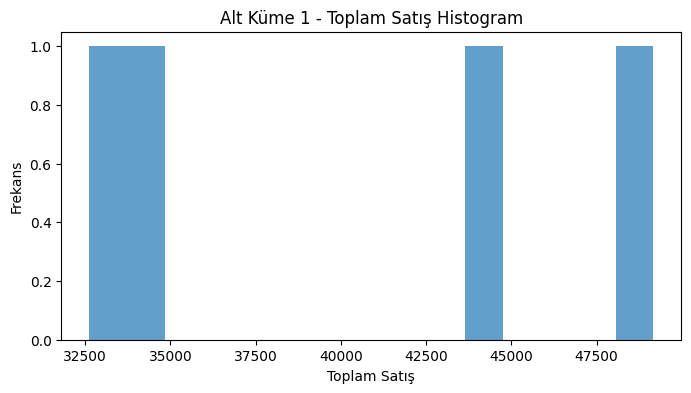

In [21]:
import matplotlib.pyplot as plt

# Örnek ürünler: yüksek hacimli ve düşük hacimli
ornek_urunler = ['303-104089', '303-104035','303-104092']

# Zaman serisi grafikleri
for urun in ornek_urunler:
    if urun in sales_matrix.index:
        aylik_satis = sales_matrix.loc[urun].filter(like='-')  # Sadece aylık satış sütunları
        plt.figure(figsize=(10, 4))
        aylik_satis.T.plot(marker='o')
        plt.title(f"{urun} - Aylık Satış Zaman Serisi")
        plt.xlabel("Ay")
        plt.ylabel("Satış Miktarı")
        plt.grid(True)
        plt.show()

for alt_kume in dbscan_cluster_0['Alt_Küme'].unique():
    subset = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == alt_kume]
    plt.figure(figsize=(8, 4))
    plt.boxplot(subset['Toplam Satış'])
    plt.title(f"Alt Küme {alt_kume} - Toplam Satış Boxplot")
    plt.ylabel("Toplam Satış")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(subset['Toplam Satış'], bins=15, alpha=0.7)
    plt.title(f"Alt Küme {alt_kume} - Toplam Satış Histogram")
    plt.xlabel("Toplam Satış")
    plt.ylabel("Frekans")
    plt.show()

In [22]:
subcluster_2 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 2]
subcluster_2

,2019-01,2019-02,2019-03,2019-04,2019-05,2019-06,2019-07,2019-08,2019-09,2019-10,...,Son Satış Tarihi,Toplam Satış,Ortalama Aylık Satış,Satış Std Sapma,Satış Yapılan Ay Sayısı,Satış Süresi (Ay),DBSCAN_Küme,CV,Satış Yapılan Ay Yüzdesi,Alt_Küme
ItemCode,,,,,,,,,,,,,,,,,,,,,
303-102788,0,0,0,12,24,0,24,12,9,12,...,2025-08-01,1847,23.0875,28.459251,60,77,0,1.232669,77.922078,2
303-102981,60,259,84,140,289,347,252,336,72,108,...,2024-06-01,15068,188.3500,235.801252,47,66,0,1.251931,71.212121,2
303-102982,12,12,24,12,0,24,132,0,24,72,...,2024-05-01,4173,52.1625,70.106509,56,65,0,1.344002,86.153846,2
303-102990,0,0,24,0,36,24,84,36,0,0,...,2025-08-01,2424,30.3000,33.637080,56,78,0,1.110135,71.794872,2
303-102992,12,0,54,37,76,0,60,72,50,43,...,2025-08-01,11969,149.6125,236.993430,68,80,0,1.584048,85.000000,2
303-102994,2,12,48,22,36,24,24,0,24,48,...,2025-07-01,2823,35.2875,33.490673,67,79,0,0.949080,84.810127,2
303-102996,0,0,24,0,36,24,24,0,36,24,...,2025-08-01,8161,102.0125,200.949108,63,78,0,1.969848,80.769231,2
303-102998,18,12,15,36,27,12,12,24,13,20,...,2025-08-01,4420,55.2500,58.091918,71,80,0,1.051437,88.750000,2
303-103000,12,36,12,34,168,36,72,35,60,108,...,2025-08-01,11819,147.7375,163.723041,72,80,0,1.108202,90.000000,2


Text(0, 0.5, 'Toplam Satış')

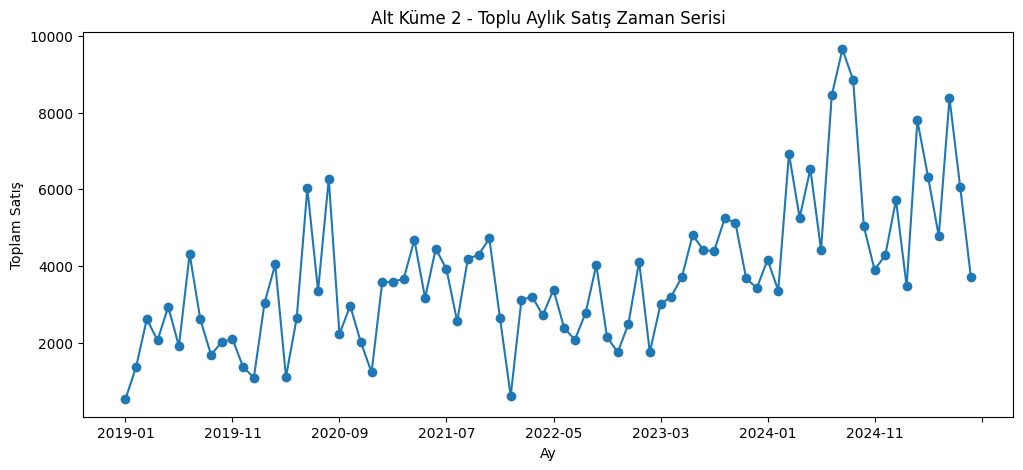

In [23]:
# Alt Küme 2'deki tüm ürünlerin aylık satışlarının toplamı
alt_kume_2 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 2]


aylik_satis_sutunlari = [col for col in alt_kume_2.columns if '-' in str(col)]
toplu_zaman_serisi = alt_kume_2[aylik_satis_sutunlari].sum(axis=0)

# Grafik
plt.figure(figsize=(12, 5))
toplu_zaman_serisi.plot(marker='o')
plt.title("Alt Küme 2 - Toplu Aylık Satış Zaman Serisi")
plt.xlabel("Ay")
plt.ylabel("Toplam Satış")

In [24]:
results = {}
for idx, row in subcluster_2.iterrows():

    series = pd.to_numeric(row.iloc[1:81], errors='coerce').dropna() 
    
    if len(series) > 5:  
        result = adfuller(series)
        results[idx] = {"ADF Statistic": result[0], "p-value": result[1], "Stationary": result[1] < 0.05}


results_df = pd.DataFrame(results).T
results_df.to_csv("adfuller_results_subcluster_2.csv")

In [25]:
import pandas as pd
import pmdarima as pm

model_results = []

for idx, row in subcluster_2.iterrows():
    # Sadece aylık satış verileri
    sales_series = pd.to_numeric(row.iloc[1:81], errors='coerce').dropna()
    
    if len(sales_series) > 10: 
        try:
            # Auto ARIMA 
            model = pm.auto_arima(sales_series,
                                  start_p=0, start_q=0,
                                  max_p=5, max_q=5,
                                  m=12,
                                  seasonal=True,
                                  trace=False,
                                  error_action='ignore',
                                  suppress_warnings=True,
                                  stepwise=True)
            
            # Model bilgileri
            model_info = {
                'ItemCode': idx,
                'order': model.order,
                'seasonal_order': model.seasonal_order,
                'aic': model.aic(),
                'bic': model.bic()
            }
            
            model_results.append(model_info)
            
        except Exception as e:
            print(f"Hata oluştu: ItemCode {idx} için ARIMA modeli kurulamadı. Hata: {e}")

model_results_df = pd.DataFrame(model_results)

model_results_df.to_csv("best_arima_models_subcluster_2.csv", index=False)

print("Model bilgileri kaydedildi.")

ModuleNotFoundError: No module named 'pmdarima'

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import warnings
import ast
warnings.filterwarnings('ignore')

# Önceden kaydedilmiş model parametreleri
model_results_df = pd.read_csv("best_arima_models_subcluster_2.csv")
subcluster_2 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 2]

all_forecasts = []

# Her bir ürün için tahmin
for idx, row in subcluster_2.iterrows():
    item_code = idx
    
    # Bu ürün için kayıtlı model parametreleri
    model_info = model_results_df[model_results_df['ItemCode'] == item_code]
    
    if not model_info.empty:
        # Model parametrelerini ayrıştırma
        try:
            order = ast.literal_eval(model_info['order'].values[0])
            seasonal_order = ast.literal_eval(model_info['seasonal_order'].values[0])
        except:
            print(f"{item_code} için parametreler ayrıştırılamadı")
            forecast_values = [np.nan] * 12
            all_forecasts.append([item_code] + forecast_values)
            continue

        sales_series = pd.to_numeric(row.iloc[1:81], errors='coerce').dropna()
        
        try:
            model = ARIMA(sales_series,
                         order=order,
                         seasonal_order=seasonal_order)
            fitted_model = model.fit()
            
            forecast = fitted_model.forecast(steps=3)
            
            forecast_values = forecast.tolist()
            all_forecasts.append([item_code] + forecast_values)
            
        except Exception as e:
            print(f"{item_code} için tahmin yapılamadı: {str(e)}")
            forecast_values = [np.nan] * 3
            all_forecasts.append([item_code] + forecast_values)
    else:
        # Model bilgisi bulunamayan ürünler
        print(f"{item_code} için model bilgisi bulunamadı")
        forecast_values = [np.nan] * 3
        all_forecasts.append([item_code] + forecast_values)


column_names = ['ItemCode'] + [1] + [2] + [3]
final_forecast_df = pd.DataFrame(all_forecasts, columns=column_names)


final_forecast_df.to_csv("arima_forecasts_subcluster_2.csv", index=False)

print("Tahminler başarıyla kaydedildi.")

In [ ]:
import pandas as pd
import pmdarima as pm

model_results = []

for idx, row in subcluster_2.iterrows():
    # Sadece aylık satış verileri
    sales_series = pd.to_numeric(row.iloc[1:80], errors='coerce').dropna()
    train_data = sales_series.iloc[:-3]
    
    if len(sales_series) > 10: 
        try:
            # Oto Arima
            model = pm.auto_arima(train_data,
                                  start_p=0, start_q=0,
                                  max_p=5, max_q=5,
                                  m=12,
                                  seasonal=True,
                                  trace=False,
                                  error_action='ignore',
                                  suppress_warnings=True,
                                  stepwise=True)
            
            model_info = {
                'ItemCode': idx,
                'order': model.order,
                'seasonal_order': model.seasonal_order,
                'aic': model.aic(),
                'bic': model.bic()
            }
            
            model_results.append(model_info)
            
        except Exception as e:
            print(f"Hata oluştu: ItemCode {idx} için ARIMA modeli kurulamadı. Hata: {e}")

model_results_df = pd.DataFrame(model_results)

model_results_df.to_csv("best_arima_models_subcluster_2.csv", index=False)

print("Model bilgileri kaydedildi.")

In [ ]:
import pandas as pd
import numpy as np
# SARIMAX modelini import edin
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
import ast

warnings.filterwarnings('ignore')

# Gerekli dosyaları yükleyin
model_results_df = pd.read_csv("best_arima_models_subcluster_2.csv")


dbscan_cluster_0 = pd.DataFrame() 

subcluster_2 = dbscan_cluster_0[dbscan_cluster_0['Alt_Küme'] == 2]


forecast_evaluation_results = []

# Her bir ürün için tahmin 
for idx, row in subcluster_2.iterrows():
    item_code = idx
    
    # Kayıtlı model parametreleri
    model_info = model_results_df[model_results_df['ItemCode'] == item_code]
    
    if not model_info.empty:
        # Model parametreleri
        try:
            # ARIMA ve SARIMAX modelleri için p,d,q parametreleri
            order = ast.literal_eval(model_info['order'].values[0])
            # SARIMAX için ek olarak P,D,Q,s parametreleri
            seasonal_order = ast.literal_eval(model_info['seasonal_order'].values[0])
        except (ValueError, SyntaxError):
            print(f"{item_code} için parametreler ayrıştırılamadı. Atlanıyor.")
            continue
            
        sales_series = pd.to_numeric(row.iloc[1:80], errors='coerce').dropna()
        
        # Eğitim ve test verileri
        test_size = 3  

        test_data = sales_series.iloc[-test_size:]
        train_data = sales_series.iloc[:-test_size]

        try:
            model = SARIMAX(train_data, order=order, seasonal_order=seasonal_order, 
                            enforce_stationarity=True, enforce_invertibility=False)
            fitted_model = model.fit()
            
            # Test verisi için tahmin
            forecast = fitted_model.forecast(steps=test_size)
            
            forecast_evaluation_results.append({
                'ItemCode': item_code,
                'Gerçek Değerler': test_data.tolist(),
                'Tahmin Edilen Değerler': forecast.tolist()
            })
            
        except Exception as e:
            print(f"{item_code} için tahmin yapılamadı: {str(e)}")
            forecast_evaluation_results.append({
                'ItemCode': item_code,
                'Gerçek Değerler': test_data.tolist(),
                'Tahmin Edilen Değerler': [np.nan] * test_size
            })
    else:
        print(f"{item_code} için model bilgisi bulunamadı. Atlanıyor.")

forecast_evaluation_df = pd.DataFrame(forecast_evaluation_results)

forecast_evaluation_df.to_csv("sarimax_forecast_evaluation_subcluster_2.csv", index=False)

print("SARIMAX tahmin değerlendirme sonuçları başarıyla kaydedildi.")

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 8  
neigh = NearestNeighbors(n_neighbors=k)
nbrs = neigh.fit(features_scaled_df)
distances, indices = nbrs.kneighbors(features_scaled_df)

k_distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.ylabel(f'{k}. En Yakın Komşu Mesafesi')
plt.xlabel('Veri Noktası Sırası (Artan Mesafeye Göre)')
plt.title(f'{k}. En Yakın Komşu Mesafesi Grafiği (DBSCAN için)')
plt.ylim(0, 10)
plt.grid(True)
plt.show()